---
### 06. Model Optimizing
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


In [2]:
# make dataset
def make_DataSet(X_train, X_val, y_train, y_val, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.long)
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_val_tensor, y_val_tensor

# train
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  tr_loss = 0

  model.train()
  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    tr_loss += loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  tr_loss /= num_batches
  return tr_loss.item()

# evaluate
def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():
    X, y = X_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(X)
    eval_loss = loss_fn(pred, y).item()
  return eval_loss, pred

# vizualize
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label='tr_err', marker='.')
  plt.plot(epochs, val_loss_list, label='val_err', marker='.')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.grid()
  plt.show()

#### Data loading

target: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


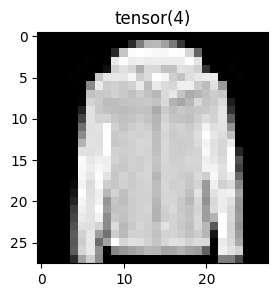

In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.FashionMNIST(
    root='data', train=True, download='True', transform = ToTensor()
)
test_dataset = datasets.FashionMNIST(
    root='data', train=False, download='True', transform = ToTensor()
)

# target 범주 확인
print('target:', train_dataset.classes)

# 이미지 확인
k = 5000
image, label = train_dataset.data[k], train_dataset.targets[k]

plt.figure(figsize=(3,3))
plt.imshow(image, cmap='gray')
plt.title(label)
plt.show()

#### 데이터 전처리
- train_dataset 6만건 중, 2만건만 사용

In [4]:
# target지정, scaling
X_train = train_dataset.data / 255
y_train = train_dataset.targets
X_test = test_dataset.data / 255
y_test = test_dataset.targets
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# 2만건 추출
X_train = X_train[:20000]
y_train = y_train[:20000]
print(X_train.shape, y_train.shape)

torch.Size([60000, 28, 28]) torch.Size([60000]) torch.Size([10000, 28, 28]) torch.Size([10000])
torch.Size([20000, 28, 28]) torch.Size([20000])


In [5]:
# 검증데이터 분리
print(X_test.shape, y_test.shape)

X_val, X_test = X_test[:5000], X_test[5000:]
y_val, y_test = y_test[:5000], y_test[5000:]
print(X_val.shape, y_val.shape, X_test.shape, y_test.shape)

torch.Size([10000, 28, 28]) torch.Size([10000])
torch.Size([5000, 28, 28]) torch.Size([5000]) torch.Size([5000, 28, 28]) torch.Size([5000])


In [6]:
# X 데이터 차원 변환
X_train = X_train.view(20000, 1, 28, 28)
X_val = X_val.view(5000, 1, 28, 28)
X_test = X_test.view(5000, 1, 28, 28)

# 텐서변환, 데이터 로더
train_TensorDS = TensorDataset(X_train, y_train)
batch_size = 64
train_loader = DataLoader(train_TensorDS, batch_size = batch_size)

---
#### Model 1 : Overfitted version

In [7]:
from torchsummary import summary

n_feature = 28*28
n_class = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 64), nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size=(n_feature,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                  [-1, 256]          65,792
              ReLU-7                  [-1, 256]               0
            Linear-8                   [-1, 64]          16,448
              ReLU-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 616,138
Trainable params: 616,138
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.35
Estimated T

epoch 5, tr loss:0.3448, val loss:0.4269
epoch 10, tr loss:0.2609, val loss:0.4743
epoch 15, tr loss:0.2117, val loss:0.4627
epoch 20, tr loss:0.1860, val loss:0.5598
epoch 25, tr loss:0.1505, val loss:0.5942
epoch 30, tr loss:0.1357, val loss:0.6668
epoch 35, tr loss:0.1180, val loss:0.7343
epoch 40, tr loss:0.1057, val loss:0.6838


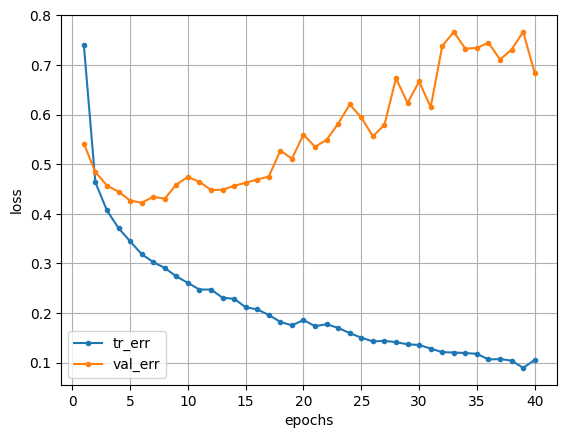

In [8]:
# train
epochs = 40
tr_loss_list, val_loss_list = [], []
for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  # 5 epoch마다 출력
  if (i + 1) % 5 == 0:
      print(f"epoch {i+1}, tr loss:{tr_loss:.4f}, val loss:{val_loss:.4f}")

# learning curve
learning_curve(tr_loss_list, val_loss_list)

In [9]:
# eval
_, pred = evaluate(X_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

report = classification_report(y_test, pred,
                               target_names=train_dataset.classes, digits=4)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8460    0.7688    0.8055       493
     Trouser     0.9804    0.9615    0.9708       519
    Pullover     0.8078    0.7808    0.7941       479
       Dress     0.8214    0.9200    0.8679       500
        Coat     0.7330    0.8309    0.7789       479
      Sandal     0.9505    0.9689    0.9596       515
       Shirt     0.7143    0.6371    0.6735       518
     Sneaker     0.9067    0.9720    0.9382       500
         Bag     0.9662    0.9641    0.9652       474
  Ankle boot     0.9875    0.9082    0.9462       523

    accuracy                         0.8714      5000
   macro avg     0.8714    0.8712    0.8700      5000
weighted avg     0.8724    0.8714    0.8706      5000



---
#### Model 2. Early Stopping

In [10]:
n_feature = 28*28
n_class = 10

model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 64), nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

epoch 5, tr loss:0.3436, val loss:0.4285
epoch 10, tr loss:0.2673, val loss:0.4486

Early stopping at epoch 10


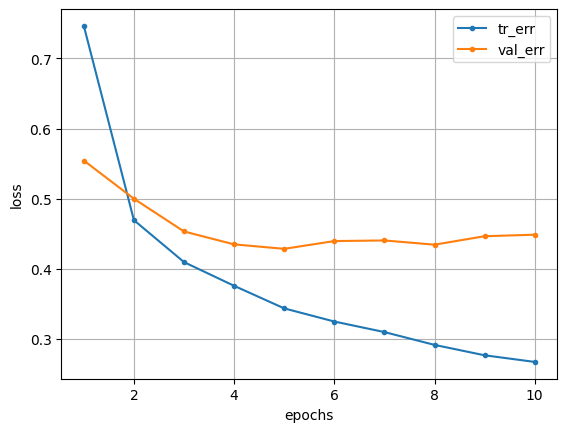

In [11]:
# train code 수정
patience = 5
counter = 0
best_loss = float('inf')

epochs = 40
tr_loss_list, val_loss_list = [], []
for i in range(epochs):
  tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model2, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  # Early Stopping 체크
  if val_loss < best_loss:
      best_loss = val_loss
      counter = 0
  else:
      counter += 1

  # 5 epoch마다 출력
  if (i + 1) % 5 == 0:
      print(f"epoch {i+1}, tr loss:{tr_loss:.4f}, val loss:{val_loss:.4f}")

  # 종료 조건
  if counter >= patience:
      print(f"\nEarly stopping at epoch {i+1}")
      break

# learning curve
learning_curve(tr_loss_list, val_loss_list)

In [12]:
# eval
_, pred = evaluate(X_test, y_test, model2, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

report = classification_report(y_test, pred,
                               target_names=train_dataset.classes, digits=4)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8388    0.7809    0.8088       493
     Trouser     0.9959    0.9461    0.9704       519
    Pullover     0.6895    0.8392    0.7571       479
       Dress     0.9085    0.8340    0.8697       500
        Coat     0.7193    0.7328    0.7260       479
      Sandal     0.9612    0.9612    0.9612       515
       Shirt     0.6782    0.6429    0.6601       518
     Sneaker     0.8944    0.9660    0.9288       500
         Bag     0.9448    0.9747    0.9595       474
  Ankle boot     0.9814    0.9063    0.9423       523

    accuracy                         0.8586      5000
   macro avg     0.8612    0.8584    0.8584      5000
weighted avg     0.8628    0.8586    0.8593      5000



---
#### Model 3. Dropout

In [13]:
n_feature = 28*28
n_class = 10
dropout_rate = 0.4

model3 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 512), nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(256, 64), nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

epoch 5, tr loss:0.4932, val loss:0.4444
epoch 10, tr loss:0.4065, val loss:0.4165
epoch 15, tr loss:0.3710, val loss:0.4191
epoch 20, tr loss:0.3493, val loss:0.3905
epoch 25, tr loss:0.3252, val loss:0.4098
epoch 30, tr loss:0.3098, val loss:0.4436
epoch 35, tr loss:0.3056, val loss:0.4151
epoch 40, tr loss:0.2985, val loss:0.4058


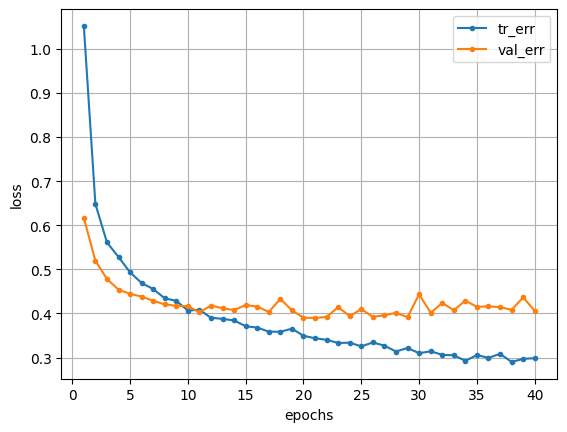

In [14]:
# train
epochs = 40
tr_loss_list, val_loss_list = [], []
for i in range(epochs):
  tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model3, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  # 5 epoch마다 출력
  if (i + 1) % 5 == 0:
      print(f"epoch {i+1}, tr loss:{tr_loss:.4f}, val loss:{val_loss:.4f}")

# learning curve
learning_curve(tr_loss_list, val_loss_list)

In [15]:
# eval
_, pred = evaluate(X_test, y_test, model3, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

report = classification_report(y_test, pred,
                               target_names=train_dataset.classes, digits=4)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8273    0.8357    0.8315       493
     Trouser     0.9901    0.9595    0.9746       519
    Pullover     0.7898    0.7766    0.7832       479
       Dress     0.8502    0.8740    0.8619       500
        Coat     0.7304    0.8539    0.7873       479
      Sandal     0.9758    0.9398    0.9575       515
       Shirt     0.7459    0.6178    0.6758       518
     Sneaker     0.9121    0.9760    0.9430       500
         Bag     0.9609    0.9852    0.9729       474
  Ankle boot     0.9665    0.9388    0.9525       523

    accuracy                         0.8756      5000
   macro avg     0.8749    0.8757    0.8740      5000
weighted avg     0.8762    0.8756    0.8746      5000



---
#### Model 4. Regulation

In [19]:
n_feature = 28*28
n_class = 10
dropout_rate = 0.4

model4 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 64), nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model4.parameters(), lr=0.001, weight_decay = 0.001)

epoch 5, tr loss:0.4073, val loss:0.4769
epoch 10, tr loss:0.3359, val loss:0.4341
epoch 15, tr loss:0.2918, val loss:0.4166
epoch 20, tr loss:0.2642, val loss:0.4305
epoch 25, tr loss:0.2420, val loss:0.4452
epoch 30, tr loss:0.2243, val loss:0.4729
epoch 35, tr loss:0.2114, val loss:0.4687
epoch 40, tr loss:0.2055, val loss:0.5540


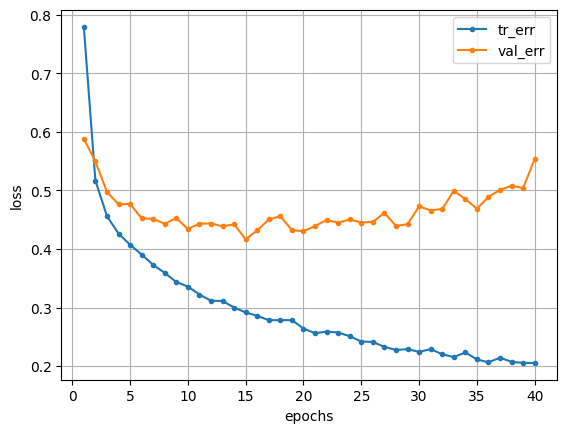

In [20]:
# train
epochs = 40
tr_loss_list, val_loss_list = [], []
for i in range(epochs):
  tr_loss = train(train_loader, model4, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model4, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  # 5 epoch마다 출력
  if (i + 1) % 5 == 0:
      print(f"epoch {i+1}, tr loss:{tr_loss:.4f}, val loss:{val_loss:.4f}")

# learning curve
learning_curve(tr_loss_list, val_loss_list)

In [18]:
# eval
_, pred = evaluate(X_test, y_test, model4, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

report = classification_report(y_test, pred,
                               target_names=train_dataset.classes, digits=4)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8075    0.7911    0.7992       493
     Trouser     0.9840    0.9499    0.9667       519
    Pullover     0.7557    0.6973    0.7253       479
       Dress     0.8249    0.8760    0.8497       500
        Coat     0.6124    0.8873    0.7246       479
      Sandal     0.9694    0.9223    0.9453       515
       Shirt     0.7462    0.4768    0.5819       518
     Sneaker     0.9065    0.9500    0.9277       500
         Bag     0.9538    0.9578    0.9558       474
  Ankle boot     0.9375    0.9465    0.9420       523

    accuracy                         0.8452      5000
   macro avg     0.8498    0.8455    0.8418      5000
weighted avg     0.8516    0.8452    0.8426      5000

